### Загрузка модели

In [1]:
#%pip install -r requirements.txt -q

In [2]:
#!python3.10 -m pip uninstall -y datasets gradio

In [3]:
import torch
from diffusers import AltDiffusionPipeline

MODEL_PATH = "AltDiffusion-m9"
model = AltDiffusionPipeline.from_pretrained(MODEL_PATH,     safety_checker=None,  
    requires_safety_checker=False)

/home/coder/envs/py310_soc_feat/lib/python3.10/site-packages/diffusers/utils/deprecation_utils.py:35: FutureWarning: The configuration file of the unet has set the default `sample_size` to smaller than 64 which seems highly unlikely .If you're checkpoint is a fine-tuned version of any of the following: 
- CompVis/stable-diffusion-v1-4 
- CompVis/stable-diffusion-v1-3 
- CompVis/stable-diffusion-v1-2 
- CompVis/stable-diffusion-v1-1 
- runwayml/stable-diffusion-v1-5 
- runwayml/stable-diffusion-inpainting 
 you should change 'sample_size' to 64 in the configuration file. Please make sure to update the config accordingly as leaving `sample_size=32` in the config might lead to incorrect results in future versions. If you have downloaded this checkpoint from the Hugging Face Hub, it would be very nice if you could open a Pull request for the `unet/config.json` file
  warnings.warn(warning + message, FutureWarning)


### Загрузка данных

In [4]:
import os
import csv
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from transformers import AutoTokenizer

DATA_DIR = "text_meme_export"
CSV_PATH = os.path.join(DATA_DIR, "metadata.csv")
IMAGES_DIR = os.path.join(DATA_DIR, "images")
IMAGE_SIZE = 512
BATCH_SIZE = 4

### Resize картинок

In [5]:
def pad_to_square(image: Image.Image, fill=(255, 255, 255)) -> Image.Image:
    w, h = image.size
    max_side = max(w, h)

    result = Image.new("RGB", (max_side, max_side), fill)
    paste_x = (max_side - w) // 2
    paste_y = (max_side - h) // 2
    result.paste(image, (paste_x, paste_y))
    return result

### Подготовка Dataloader'a

In [6]:
class AltDiffusionCSVSet(Dataset):
    def __init__(self, csv_path, images_dir, tokenizer, image_size=512):
        self.images_dir = images_dir
        self.tokenizer = tokenizer

        self.rows = []
        with open(csv_path, "r", encoding="utf-8") as f:
            reader = csv.DictReader(f)
            for row in reader:
                self.rows.append(row)

        self.image_transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
        ])

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        row = self.rows[idx]

        text = str(row["description"]).strip()
        image_path = os.path.join(self.images_dir, row["image_filename"])

        image = Image.open(image_path).convert("RGB")
        image = pad_to_square(image)
        pixel_values = self.image_transform(image)

        text_inputs = self.tokenizer(
            text,
            max_length=self.tokenizer.model_max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )

        return {
            "pixel_values": pixel_values,
            "input_ids": text_inputs["input_ids"].squeeze(0),
            "attention_mask": text_inputs["attention_mask"].squeeze(0),
            "text": text,
            "idx": idx,
        }


def collate_fn(batch):
    return {
        "pixel_values": torch.stack([x["pixel_values"] for x in batch]),
        "input_ids": torch.stack([x["input_ids"] for x in batch]),
        "attention_mask": torch.stack([x["attention_mask"] for x in batch]),
        "texts": [x["text"] for x in batch],
        "idxs": [x["idx"] for x in batch],
    }


tokenizer = AutoTokenizer.from_pretrained(
    MODEL_PATH,
    subfolder="tokenizer",
    use_fast=False,
)

train_dataset = AltDiffusionCSVSet(
    csv_path=CSV_PATH,
    images_dir=IMAGES_DIR,
    tokenizer=tokenizer,
    image_size=IMAGE_SIZE,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False,
    collate_fn=collate_fn,
)

### Inference модели по собранным данным

In [7]:
model = model.to('cuda')

prompt = next(iter(train_loader))["texts"][0]

image = model(
    prompt=prompt,
    num_inference_steps=20,
    guidance_scale=7.5,
    height=512,
    width=512,
).images[0]


  0%|          | 0/29 [00:00<?, ?it/s]

In [8]:
from PIL import Image, ImageDraw, ImageFont
import textwrap


def render_meme(image, caption):
    WIDTH = image.width
    PADDING = 20
    MAX_LINES = 3
    FONT_SIZE = 32
    try:
        font = ImageFont.truetype("DejaVuSans.ttf", FONT_SIZE)
    except:
        font = ImageFont.load_default()
    wrapped_lines = textwrap.wrap(caption, width=25)

    if len(wrapped_lines) > MAX_LINES:
        wrapped_lines = wrapped_lines[:MAX_LINES]
    dummy_img = Image.new("RGB", (WIDTH, 100))
    draw = ImageDraw.Draw(dummy_img)

    line_heights = []
    for line in wrapped_lines:
        bbox = draw.textbbox((0, 0), line, font=font)
        h = bbox[3] - bbox[1]
        line_heights.append(h)

    text_height = sum(line_heights) + PADDING * 2 + 10 * (len(wrapped_lines) - 1)
    new_height = image.height + text_height
    new_image = Image.new("RGB", (WIDTH, new_height), "white")
    new_image.paste(image, (0, 0))
    draw = ImageDraw.Draw(new_image)

    y_text = image.height + PADDING
    for line in wrapped_lines:
        bbox = draw.textbbox((0, 0), line, font=font)
        text_width = bbox[2] - bbox[0]
        x_text = (WIDTH - text_width) // 2
        draw.text((x_text, y_text), line, fill="black", font=font)
        y_text += (bbox[3] - bbox[1]) + 10
    return new_image

with_text = render_meme(image, '')
type(with_text)

PIL.Image.Image

### Построим baseline с LoRA-адаптером:

Посмотрим на компоненты модели:

In [9]:
model.components

{'vae': AutoencoderKL(
   (encoder): Encoder(
     (conv_in): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (down_blocks): ModuleList(
       (0): DownEncoderBlock2D(
         (resnets): ModuleList(
           (0-1): 2 x ResnetBlock2D(
             (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
             (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
             (norm2): GroupNorm(32, 128, eps=1e-06, affine=True)
             (dropout): Dropout(p=0.0, inplace=False)
             (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
             (nonlinearity): SiLU()
           )
         )
         (downsamplers): ModuleList(
           (0): Downsample2D(
             (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2))
           )
         )
       )
       (1): DownEncoderBlock2D(
         (resnets): ModuleList(
           (0): ResnetBlock2D(
             (norm1): GroupNorm(32, 128, eps=1e

In [10]:
IMAGE_SIZE = 512
NUM_EPOCHS = 7
MAX_GRAD_NORM = 1.0
LORA_RANK = 10
SEED = 42

In [11]:
import os
import torch
import torch.nn.functional as F
from torch.optim import AdamW
from tqdm.auto import tqdm
import random

from transformers import AutoTokenizer, CLIPTextModel
from diffusers import AutoencoderKL, DDPMScheduler, UNet2DConditionModel

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float32


def set_seed(seed):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
set_seed(SEED)


In [12]:
tokenizer = model.tokenizer
text_encoder = model.text_encoder
vae = model.vae
unet = model.unet
scheduler = model.scheduler

print("tokenizer:", type(tokenizer))
print("text_encoder:", type(text_encoder))
print("vae:", type(vae))
print("unet:", type(unet))
print("scheduler:", type(model.scheduler))

tokenizer: <class 'transformers.models.xlm_roberta.tokenization_xlm_roberta.XLMRobertaTokenizer'>
text_encoder: <class 'diffusers.pipelines.alt_diffusion.modeling_roberta_series.RobertaSeriesModelWithTransformation'>
vae: <class 'diffusers.models.vae.AutoencoderKL'>
unet: <class 'diffusers.models.unet_2d_condition.UNet2DConditionModel'>
scheduler: <class 'diffusers.schedulers.scheduling_pndm.PNDMScheduler'>


In [13]:
import math
import torch
import torch.nn as nn

class LoRALinear(nn.Module):
    def __init__(self, base_layer, r = 8, alpha= 8.0):
        super().__init__()
        self.base = base_layer
        self.r = r
        self.alpha = alpha
        self.scaling = alpha / r

        in_features = base_layer.in_features
        out_features = base_layer.out_features
        for p in self.base.parameters():
            p.requires_grad = False
        self.lora_A = nn.Linear(in_features, r, bias=False)
        self.lora_B = nn.Linear(r, out_features, bias=False)
        nn.init.kaiming_uniform_(self.lora_A.weight, a=math.sqrt(5))
        nn.init.zeros_(self.lora_B.weight)

    def forward(self, x):
        return self.base(x) + self.lora_B(self.lora_A(x)) * self.scaling

In [14]:
def apply_lora_to_unet(unet, r = 8, alpha = 8.0):
    replaced = []

    for module_name, module in unet.named_modules():
        for attr in ["to_q", "to_k", "to_v"]:
            if hasattr(module, attr):
                child = getattr(module, attr)
                if isinstance(child, nn.Linear):
                    setattr(module, attr, LoRALinear(child, r=r, alpha=alpha).to(device))
                    replaced.append(f"{module_name}.{attr}")

        if hasattr(module, "to_out"):
            to_out = getattr(module, "to_out")
            if isinstance(to_out, (nn.ModuleList, nn.Sequential)) and len(to_out) > 0:
                if isinstance(to_out[0], nn.Linear):
                    to_out[0] = LoRALinear(to_out[0], r=r, alpha=alpha).to(device)
                    replaced.append(f"{module_name}.to_out.0")

    return replaced

In [15]:
vae.requires_grad_(False)
text_encoder.requires_grad_(False)
unet.requires_grad_(False)

replaced_layers = apply_lora_to_unet(unet, r=LORA_RANK, alpha=8.0)

print("Replaced layers:", len(replaced_layers))
print(replaced_layers[:20])

Replaced layers: 128
['down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_q', 'down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_k', 'down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_v', 'down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_out.0', 'down_blocks.0.attentions.0.transformer_blocks.0.attn2.to_q', 'down_blocks.0.attentions.0.transformer_blocks.0.attn2.to_k', 'down_blocks.0.attentions.0.transformer_blocks.0.attn2.to_v', 'down_blocks.0.attentions.0.transformer_blocks.0.attn2.to_out.0', 'down_blocks.0.attentions.1.transformer_blocks.0.attn1.to_q', 'down_blocks.0.attentions.1.transformer_blocks.0.attn1.to_k', 'down_blocks.0.attentions.1.transformer_blocks.0.attn1.to_v', 'down_blocks.0.attentions.1.transformer_blocks.0.attn1.to_out.0', 'down_blocks.0.attentions.1.transformer_blocks.0.attn2.to_q', 'down_blocks.0.attentions.1.transformer_blocks.0.attn2.to_k', 'down_blocks.0.attentions.1.transformer_blocks.0.attn2.to_v', 'down_blocks.0.attentions.1.transfor

In [16]:
trainable_params = [p for p in unet.parameters() if p.requires_grad]

print("Trainable params:", sum(p.numel() for p in trainable_params))
print("Total params:", sum(p.numel() for p in unet.parameters()))

Trainable params: 1992960
Total params: 861513924


In [17]:
optimizer = torch.optim.AdamW(
    trainable_params,
    lr=5e-5,
    weight_decay=1e-2
)

In [18]:
from tqdm import tqdm 

unet.train()
vae.eval()
text_encoder.eval()

for epoch in tqdm(range(NUM_EPOCHS), desc="Epoch"):
    for batch in train_loader:
        pixel_values = batch["pixel_values"].to(device, dtype=dtype)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        with torch.no_grad():
            latents = vae.encode(pixel_values).latent_dist.sample()
            latents = latents * 0.18215

        noise = torch.randn_like(latents)
        batch_siz = latents.shape[0]

        timesteps = torch.randint(
            0,
            scheduler.config.num_train_timesteps,
            (batch_siz,),
            device=latents.device,
            dtype=torch.long,
        )
        noisy_latents = scheduler.add_noise(latents, noise, timesteps)
        with torch.no_grad():
            encoder_hidden_states = text_encoder(
                input_ids=input_ids,
                attention_mask=attention_mask,
            )[0]

        model_pred = unet(
            noisy_latents,
            timesteps,
            encoder_hidden_states=encoder_hidden_states,
        ).sample

        loss = F.mse_loss(model_pred.float(), noise.float(), reduction="mean")

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(trainable_params, 1.0)
        optimizer.step()

Epoch: 100%|██████████| 7/7 [42:29:22<00:00, 21851.71s/it]  


In [19]:
#!pip freeze > requirements.txt

In [20]:
unet.eval();

  0%|          | 0/29 [00:00<?, ?it/s]

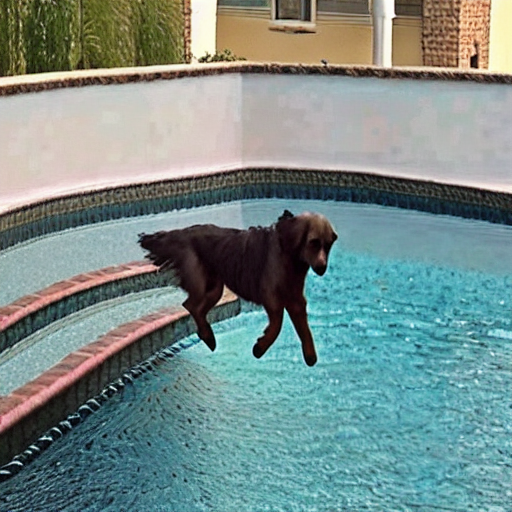

In [21]:
prompt = "На фотографии изображена собака, погруженная почти с головой в бассейн"

image_first = model(
    prompt=prompt,
    num_inference_steps=20,
    guidance_scale=7.5,
    height=512,
    width=512,
).images[0]
image_first.save('image_3.png')
image_first

  0%|          | 0/29 [00:00<?, ?it/s]

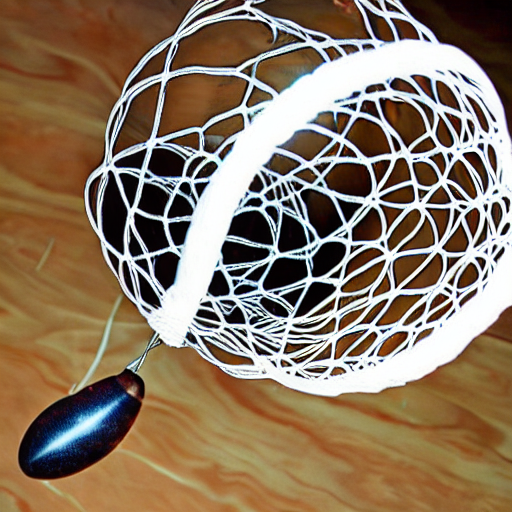

In [22]:
prompt = "Креветка в огне забрасывает баскетбольный мяч в баскетбольное кольцо"

image_second = model(
    prompt=prompt,
    num_inference_steps=20,
    guidance_scale=7.5,
    height=512,
    width=512,
).images[0]
image_second.save('image_4.png')
image_second